In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.linalg import toeplitz
from tqdm import tqdm

In [24]:
file_path = r"C:/Users/Prema/Downloads/speechprocessingfiles/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav"
signal_data, sr = librosa.load(file_path, sr=None)
print("Signal length:", len(signal_data))
print("Sampling rate:", sr)

Signal length: 29911
Sampling rate: 8000


### Raw WAV Signal

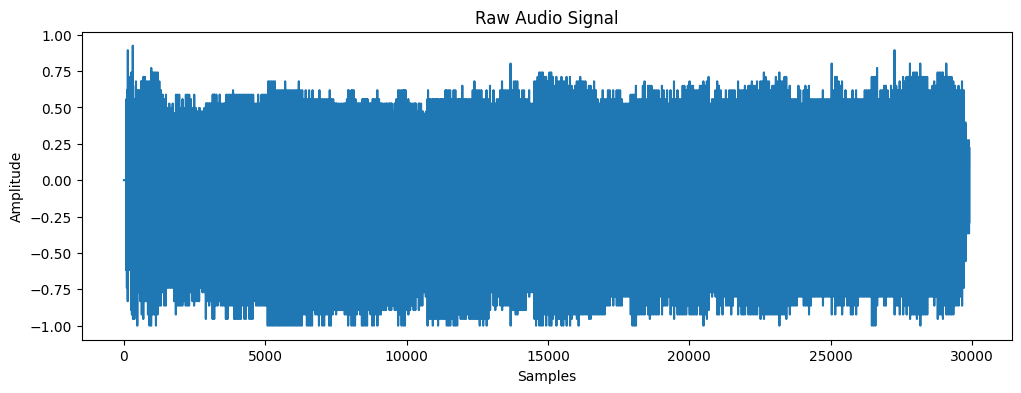

In [4]:
plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("Raw Audio Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

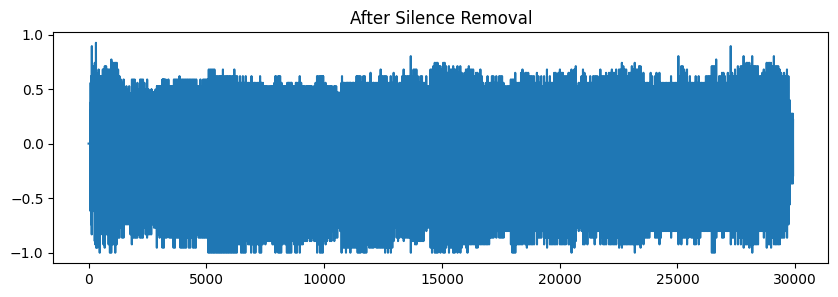

In [25]:
y_trimmed, _ = librosa.effects.trim(signal_data, top_db=20)
plt.figure(figsize=(10,3))
plt.plot(y_trimmed)
plt.title("After Silence Removal")
plt.show()

### Preprocessing (Normalization)

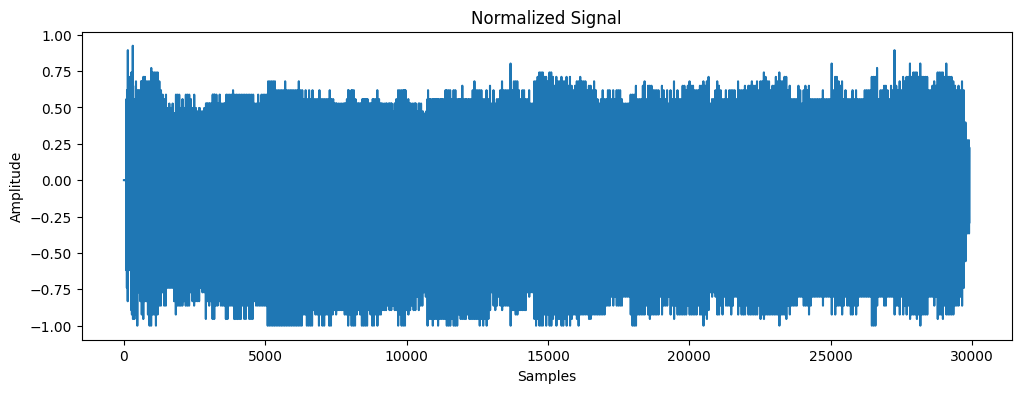

In [5]:
signal = signal / np.max(np.abs(signal))

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("Normalized Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [29]:
#Boosts high frequencies (important for LPC).
pre_emphasis = 0.97
y_preemph = np.append(signal_data[0], signal_data[1:] - pre_emphasis * signal_data[:-1])

# Speech is quasi-stationary → analyze in small frames.(framing)
frame_length = int(0.02 * sr)
frame_step = int(0.010 * sr)

frames = librosa.util.frame(
    y_preemph,
    frame_length=frame_length,
    hop_length=frame_step
).T

print("Number of frames:", frames.shape[0])
print("Frame size:", frames.shape[1])

#Reduces spectral leakage(hamming window)
frames_windowed = frames * np.hamming(frame_length)

# At the end of preprocessing, you store or pass forward:
frames_windowed



Number of frames: 372
Frame size: 160


array([[ 3.82456114e-05,  1.15251662e-06, -3.69098748e-06, ...,
        -1.93186729e-03, -7.08316125e-03, -1.09834433e-02],
       [ 2.35184908e-02, -7.56243828e-03, -3.48978379e-02, ...,
         1.19083608e-02,  1.78843782e-02,  5.65346479e-03],
       [ 1.44908476e-02,  2.51185252e-02,  1.92464417e-02, ...,
        -8.28037750e-03, -4.46939473e-02, -6.29193306e-02],
       ...,
       [-6.73274755e-03, -2.22689650e-03,  6.25468289e-03, ...,
        -1.30664874e-02, -1.44007845e-02, -6.36162639e-03],
       [ 1.29120398e-02, -2.61387932e-03, -2.43734536e-02, ...,
         3.59436051e-03, -3.98928554e-03, -6.07432246e-03],
       [ 6.90101147e-03,  1.53513372e-02,  1.49555521e-02, ...,
        -2.10999391e-03,  1.17087096e-02,  1.06338525e-02]])

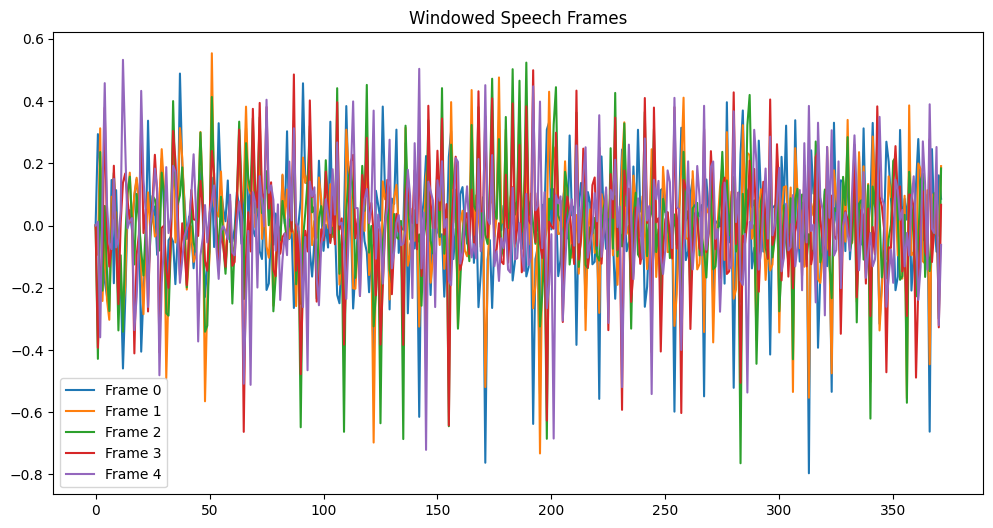

In [30]:
# Plot few frames
plt.figure(figsize=(12,6))
for i in range(5):
    plt.plot(frames[:, i], label=f"Frame {i}")
plt.title("Windowed Speech Frames")
plt.legend()
plt.show()

### LPC Function

In [7]:
def lpc_coefficients(frame, order):
    autocorr = np.correlate(frame, frame, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    
    R = autocorr[:order+1]
    R_matrix = toeplitz(R[:-1])
    r_vector = R[1:]
    
    a = np.linalg.solve(R_matrix, r_vector)
    a = np.concatenate(([1], -a))
    
    return a

### LPC Coefficients

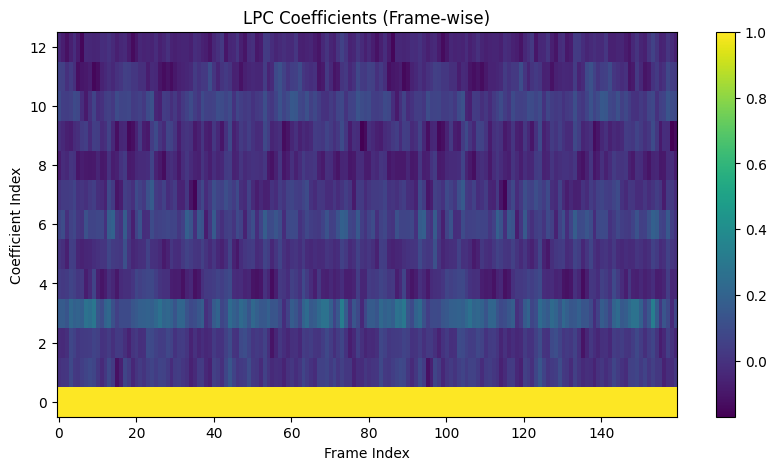

In [31]:
lpc_order = 12
lpc_all = []

for i in range(frames.shape[1]):
    lpc = lpc_coefficients(frames[:, i], lpc_order)
    lpc_all.append(lpc)

lpc_all = np.array(lpc_all)

plt.figure(figsize=(10,5))
plt.imshow(lpc_all.T, aspect='auto', origin='lower')
plt.colorbar()
plt.title("LPC Coefficients (Frame-wise)")
plt.xlabel("Frame Index")
plt.ylabel("Coefficient Index")
plt.show()

### Residual Signal

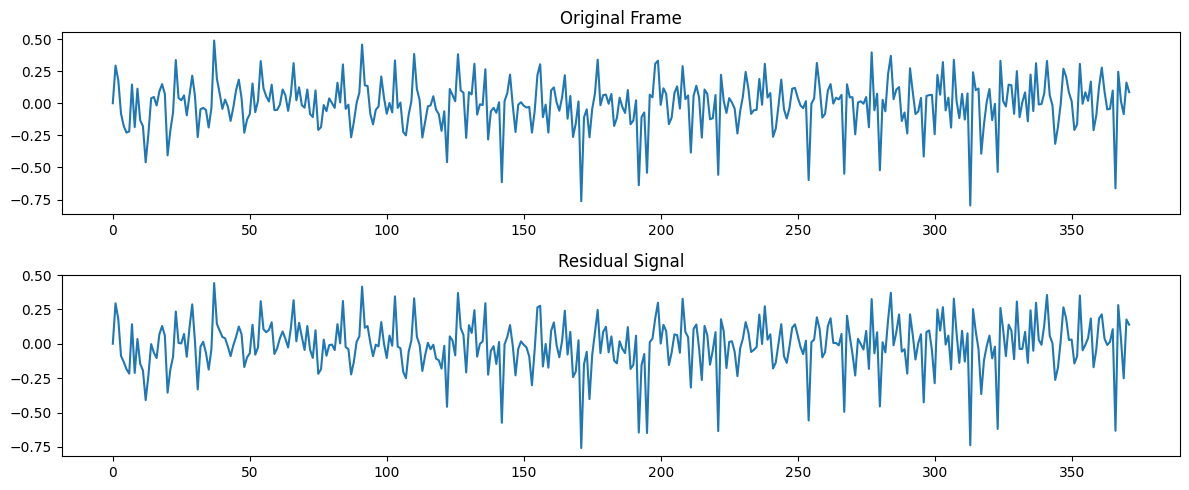

In [36]:
frame_example = frames[:, 0]
lpc = lpc_coefficients(frame_example, lpc_order)

residual = lfilter(lpc, [1], frame_example)

plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.plot(frame_example)
plt.title("Original Frame")

plt.subplot(2,1,2)
plt.plot(residual)
plt.title("Residual Signal")

plt.tight_layout()
plt.show()

### Residual Energy

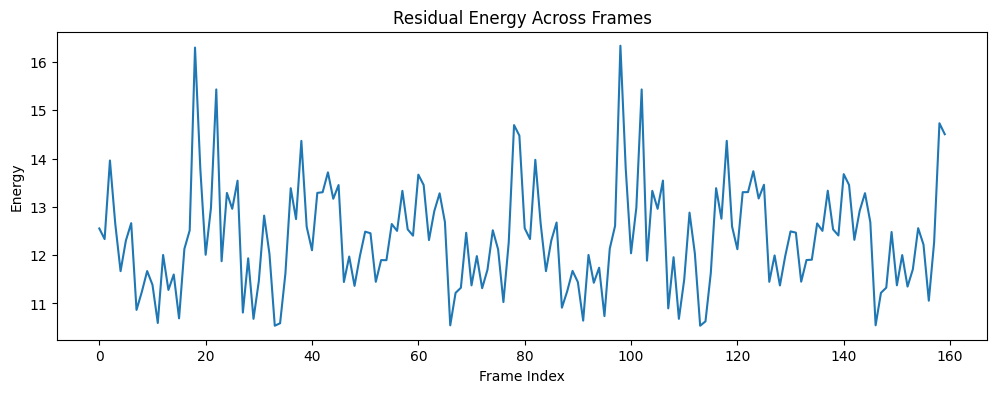

In [33]:
energies = []

for i in range(frames.shape[1]):
    frame = frames[:, i]
    lpc = lpc_coefficients(frame, lpc_order)
    residual = lfilter(lpc, [1], frame)
    
    energy = np.sum(residual**2)
    energies.append(energy)

plt.figure(figsize=(12,4))
plt.plot(energies)
plt.title("Residual Energy Across Frames")
plt.xlabel("Frame Index")
plt.ylabel("Energy")
plt.show()

### Feature Vector Formation

In [37]:
lpc_mean = np.mean(lpc_all, axis=0)
energy_mean = np.mean(energies)

feature_vector = np.concatenate([lpc_mean, [energy_mean]])

print("Feature Vector:", feature_vector)
print("Length:", len(feature_vector))

Feature Vector: [ 1.00000000e+00  2.12350843e-02  1.66617963e-02  1.59025760e-01
 -1.49483359e-02  4.65493405e-05  6.66460750e-02  1.53244273e-02
 -3.90503459e-02 -1.83030244e-02  5.15752916e-02 -1.89098882e-02
 -4.29800376e-02  1.23676827e+01]
Length: 14


In [12]:
def extract_features(file_path, lpc_order=12):
    signal, sr = librosa.load(file_path, sr=None)
    signal = signal / np.max(np.abs(signal))
    
    frame_length = int(0.02 * sr)
    hop_length = int(0.01 * sr)
    
    frames = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length)
    
    lpc_features = []
    energies = []
    
    for i in range(frames.shape[1]):
        frame = frames[:, i]
        
        lpc = lpc_coefficients(frame, lpc_order)
        residual = lfilter(lpc, [1], frame)
        
        energy = np.sum(residual**2)
        
        lpc_features.append(lpc)
        energies.append(energy)
    
    lpc_mean = np.mean(lpc_features, axis=0)
    energy_mean = np.mean(energies)
    
    return np.concatenate([lpc_mean, [energy_mean]])

In [17]:
metadata_path = r"C:/Users/Prema/Downloads/Speech processing/Demographics_age_sex.xlsx"
metadata = pd.read_excel(metadata_path)

audio_folder = r"C:/Users/Prema/Downloads/speechprocessingfiles"

X, y = [], []

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
    file_path = os.path.join(audio_folder, row['Sample ID'] + ".wav")
    
    if not os.path.exists(file_path):
        print("Missing:", file_path)
        continue
    
    features = extract_features(file_path)
    
    X.append(features)
    y.append(1 if row['Label'] == 'PwPD' else 0)

X = np.array(X)
y = np.array(y)

print("Final Dataset:", X.shape)

100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [00:08<00:00,  9.23it/s]

Final Dataset: (81, 14)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.47058823529411764
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         9
           1       0.40      0.25      0.31         8

    accuracy                           0.47        17
   macro avg       0.45      0.46      0.44        17
weighted avg       0.45      0.47      0.45        17



### Predict on FULL dataset

In [41]:
y_pred_all = model.predict(X)
y_prob_all = model.predict_proba(X)[:,1]

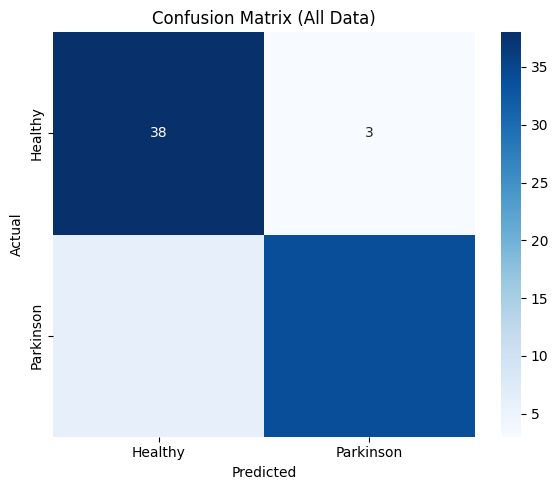

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_full = confusion_matrix(y, y_pred_all)

plt.figure(figsize=(6,5))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (All Data)")

plt.tight_layout()
plt.savefig("confusion_matrix_full.png", dpi=300)
plt.show()

### 2. Feature Importance 

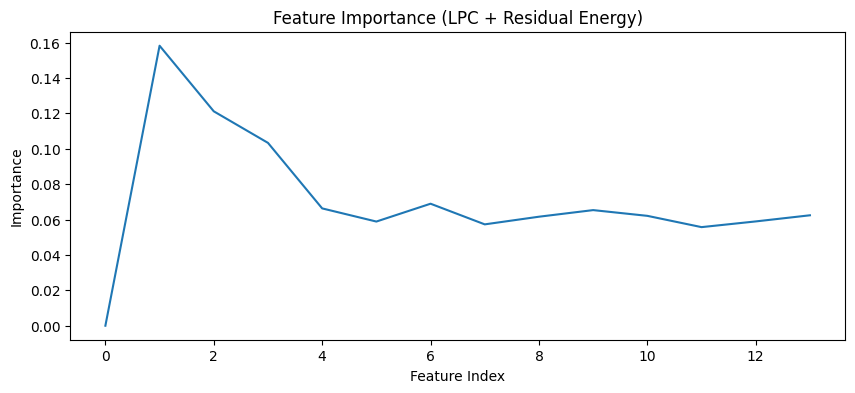

In [20]:
importance = model.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importance)
plt.title("Feature Importance (LPC + Residual Energy)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

### 3. Cross Validation 

In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.52941176 0.4375     0.4375     0.4375     0.75      ]
Mean accuracy: 0.5183823529411764


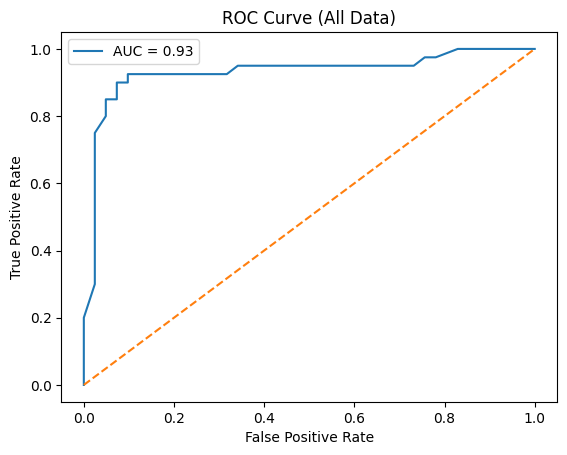

In [43]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y, y_prob_all)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Data)")
plt.legend()

plt.savefig("roc_curve_full.png", dpi=300)
plt.show()

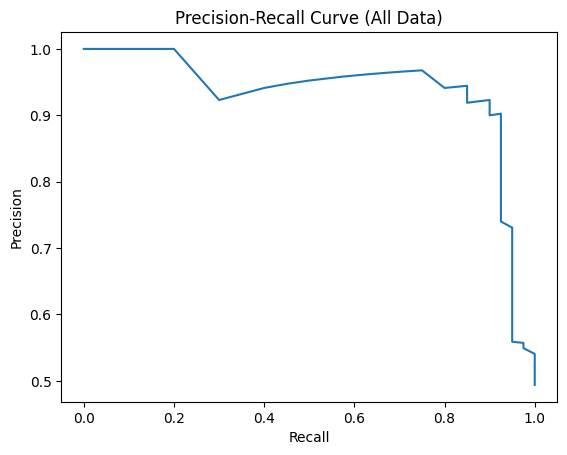

In [44]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y, y_prob_all)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (All Data)")

plt.savefig("pr_curve_full.png", dpi=300)
plt.show()

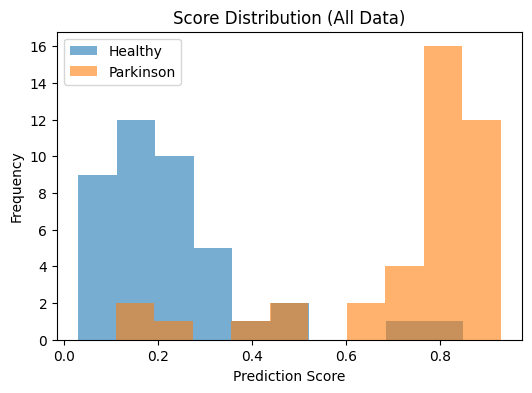

In [45]:
plt.figure(figsize=(6,4))

plt.hist(y_prob_all[y==0], bins=10, alpha=0.6, label="Healthy")
plt.hist(y_prob_all[y==1], bins=10, alpha=0.6, label="Parkinson")

plt.xlabel("Prediction Score")
plt.ylabel("Frequency")
plt.title("Score Distribution (All Data)")
plt.legend()

plt.savefig("score_distribution_full.png", dpi=300)
plt.show()